<div style="background: linear-gradient(135deg, #0d0d0d, #1a1a2e, #16213e);
            padding: 36px; border-radius: 16px; text-align: center; font-family: Georgia, serif;">

  <h1 style="color: #f0e6d3; font-size: 36px; margin: 0; letter-spacing: 2px;">
    🎯 FocusIQ v3
  </h1>

  <p style="color: #cfcfcf; font-size: 15px; margin: 12px 0 6px 0;">
    Why do we lose focus even when we want to study?
  </p>

  <p style="color: #a0c4ff; font-size: 14px; margin: 0;">
    FocusIQ analyzes self-reportable daily habits to predict focus level and
    procrastination risk.
  </p>

</div>

<div style="margin-top:18px; font-family:'Segoe UI',sans-serif; max-width:760px; color:#e0e0e0;">

<p style="font-size:14px;">
<b>What changed in v3:</b> the previous version's <code>focus_score</code> target was a
deterministic formula built directly from the same features the model then trained on —
the model was just re-deriving that formula, not learning a real pattern. This version:
</p>

<ul style="line-height:1.8; font-size:14px;">
  <li>Uses <b>real student records</b> (UCI Student Performance dataset) for structural features
      like past failures, free time, going out, family relationships, and absences</li>
  <li>Adds self-reportable habit features (sleep, phone usage, stress, motivation) with realistic
      noise and loose real-world correlations — not pure random noise, not exact formulas</li>
  <li>Grounds <code>focus_score</code> partly in real academic outcomes (G1/G2 grades) that are
      <b>excluded from the model's input features</b>, plus genuine random noise, so the model
      has to actually generalize rather than reverse a formula</li>
  <li>Drops the Google Colab / Drive dependency so this runs anywhere</li>
</ul>

</div>


---
## 📦 Part 1 — Setup & Libraries

In [81]:
# ─────────────────────────────────────────────────────────────────
#  Imports
# ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries loaded!")

✅ All libraries loaded!


---
## 📊 Part 2 — Dataset: Real Features + Grounded Simulation

Source: **UCI Student Performance dataset** (`student-mat.csv`, 395 students, semicolon-delimited).

**Real columns used directly** (not invented): `failures`, `freetime`, `goout`, `famrel`,
`absences`, `studytime` (mapped to honest hour ranges — it's an ordinal bucket, not a precise
number), `health` (renamed `health_status`).

**Self-reportable habit features simulated** (the source dataset has no wellness/focus survey,
so these don't exist in real data): `sleep_hours`, `phone_usage_hrs`, `stress_level`,
`motivation_level`, `exercise_done`. Each is built with a *loose* real-world correlation to a
real column plus meaningful random noise — e.g. more time going out → less sleep, on average,
with individual variation — instead of being pure independent noise.

**Target (`focus_score`)** is grounded partly in real G1/G2 grades (as a proxy for baseline
ability to stay on task) *plus* the habit features *plus* random noise — and G1/G2 are excluded
from the model's training features, so the model must learn from self-reportable inputs alone,
same as a real user would provide.

In [82]:
# ─────────────────────────────────────────────────────────────────
#  Load real data (note: semicolon-delimited, not comma)
# ─────────────────────────────────────────────────────────────────
df = pd.read_csv("student-mat (1).csv", sep=";")
print("Loaded:", df.shape)

Loaded: (395, 33)


In [83]:
# ─────────────────────────────────────────────────────────────────
#  Real features, honestly interpreted
# ─────────────────────────────────────────────────────────────────

# studytime is an ORDINAL bucket (1=<2h, 2=2-5h, 3=5-10h, 4=>10h) -> map to
# honest midpoint hours instead of pretending it's precise
studytime_map = {1: 1.5, 2: 3.5, 3: 7.5, 4: 10.0}
df['study_hours']   = df['studytime'].map(studytime_map)
df['health_status'] = df['health']   # 1 (bad) - 5 (good), real
# failures, freetime, goout, famrel, absences already have honest names

print("✅ Real features mapped")

✅ Real features mapped


In [84]:
# ─────────────────────────────────────────────────────────────────
#  Simulated self-report features (grounded, not pure noise)
# ─────────────────────────────────────────────────────────────────
n = len(df)

df['sleep_hours'] = np.clip(
    7.5 - 0.3 * df['goout'] + 0.3 * df['health_status']
    + np.random.normal(0, 1.1, n), 3, 10
)

df['phone_usage_hrs'] = np.clip(
    2.0 + 0.6 * df['freetime'] + 0.4 * df['goout']
    + np.random.normal(0, 1.3, n), 0, 12
)

df['stress_level'] = np.clip(
    5.0 - 0.5 * df['health_status']
    - 0.4 * df['famrel']
    + 0.6 * df['failures']
    + np.random.normal(0, 1.4, n),
    0,
    10
)

df['motivation_level'] = np.clip(
    3.0 + 0.5 * df['study_hours'] + 0.3 * df['health_status'] - 0.8 * df['failures']
    + np.random.normal(0, 1.5, n), 1, 10
)

df['exercise_done'] = (
    np.random.rand(n) < (0.3 + 0.08 * df['health_status'])
).astype(int)

# Going out is converted from the original UCI 1–5 frequency scale
# into an estimated number of hours (0–6 hours).
df['going_out_hours'] = np.clip(
    (df['goout'] - 1) * 1.5,
    0,
    6
)

print("✅ Habit features simulated")

✅ Habit features simulated


In [85]:
# ─────────────────────────────────────────────────────────────────
#  Targets: focus_score (regression) and procrastination_risk (classification)
# ─────────────────────────────────────────────────────────────────

# Real academic outcome, used ONLY to help ground the target -- excluded
# from the model's training features (see Part 4)
academic_baseline = (df['G1'] + df['G2']) / 2

focus_raw = (
    3.5 * df['study_hours']
    + 3.0 * df['sleep_hours']
    + 3.0 * df['motivation_level']
    - 3.0 * df['stress_level']
    - 2.5 * df['phone_usage_hrs']
    - 1.0 * df['goout']
    + np.random.normal(0, 3.0, n)
)

df['focus_score'] = np.clip(
    100 * (
        (focus_raw - focus_raw.quantile(0.05))
        /
        (focus_raw.quantile(0.95) - focus_raw.quantile(0.05))
    ),
    0,
    100
)

proc_raw = (
      0.5 * df['phone_usage_hrs']
    + 0.4 * df['goout']
    + 0.3 * df['freetime']
    + 0.3 * df['stress_level']
    - 0.5 * df['motivation_level']
    + np.random.normal(0, 2.2, n)
)

df['procrastination_risk'] = pd.cut(
    proc_raw,
    bins=[-np.inf, np.percentile(proc_raw, 33), np.percentile(proc_raw, 66), np.inf],
    labels=['Low', 'Medium', 'High']
)

print(df['procrastination_risk'].value_counts())
print()
print(df[['study_hours','sleep_hours','phone_usage_hrs','stress_level',
          'motivation_level','failures','freetime','goout','famrel',
          'absences','health_status','focus_score']].describe().round(2))

procrastination_risk
High      134
Low       131
Medium    130
Name: count, dtype: int64

       study_hours  sleep_hours  phone_usage_hrs  stress_level  \
count       395.00       395.00           395.00        395.00   
mean          4.07         7.64             5.13          2.11   
std           2.50         1.11             1.47          1.53   
min           1.50         4.23             0.30          0.00   
25%           1.50         6.94             4.17          0.85   
50%           3.50         7.65             5.20          1.99   
75%           3.50         8.39             6.09          3.17   
max          10.00        10.00             9.00          7.03   

       motivation_level  failures  freetime   goout  famrel  absences  \
count            395.00    395.00    395.00  395.00  395.00    395.00   
mean               5.89      0.33      3.24    3.11    3.94      5.71   
std                2.06      0.74      1.00    1.11    0.90      8.00   
min                1.00

---
## 🔍 Part 3 — Exploratory Data Analysis

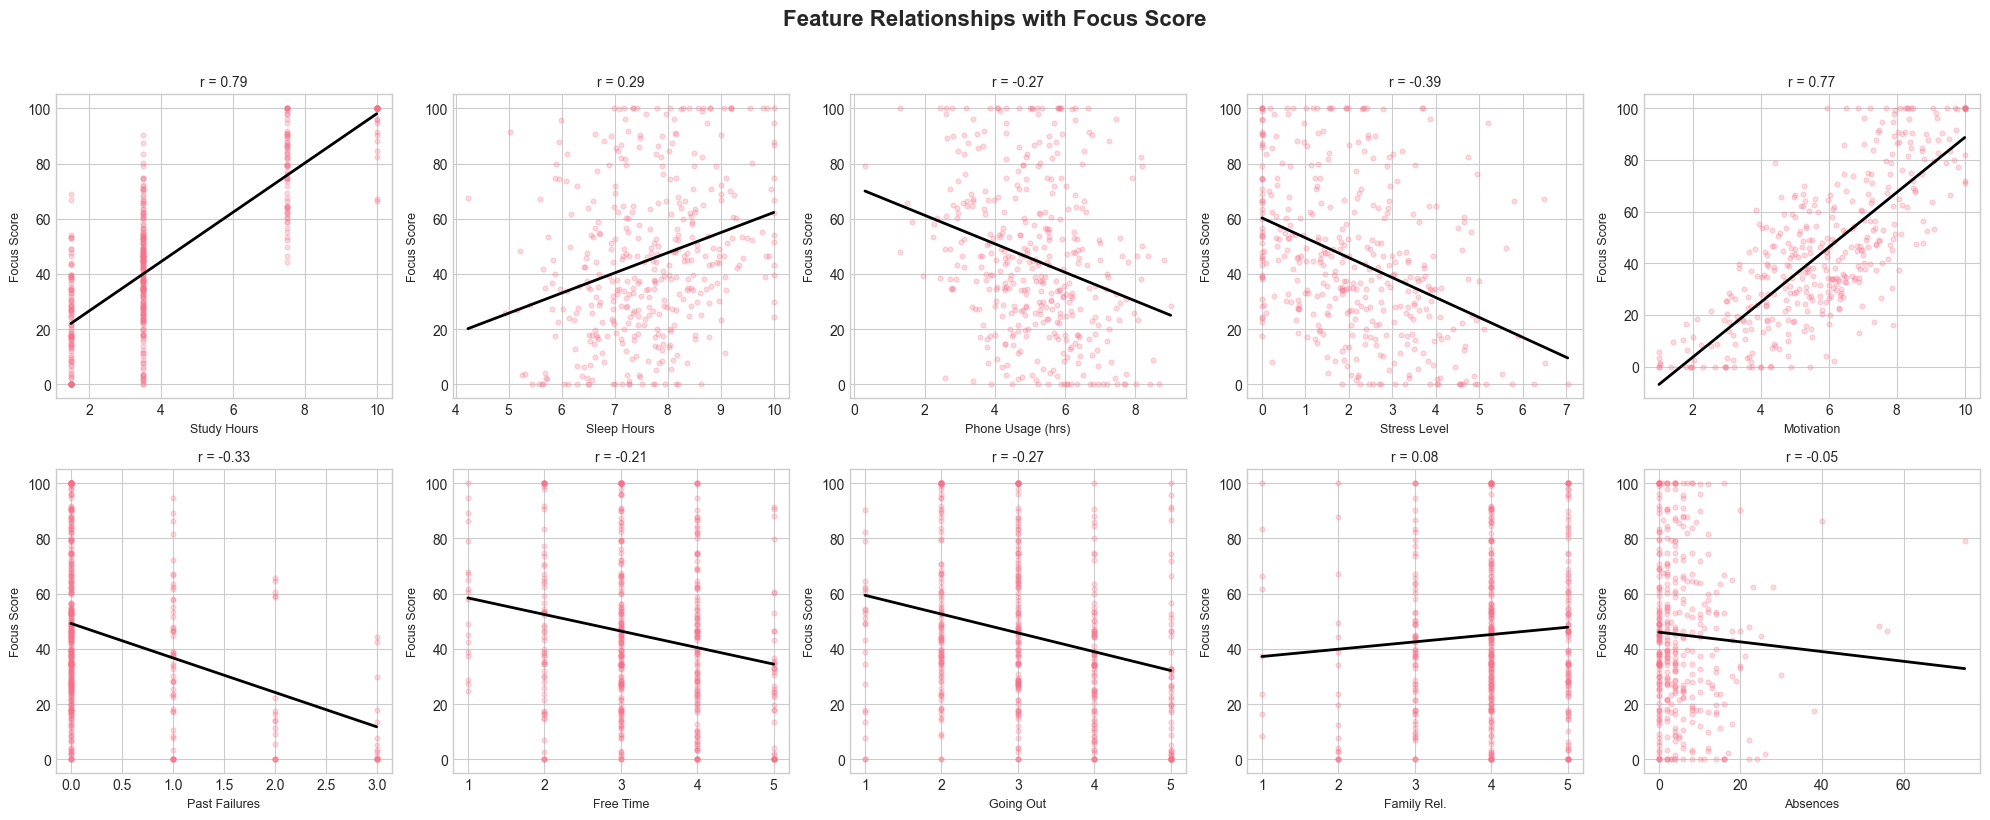

In [86]:
feature_cols = ['study_hours','sleep_hours','phone_usage_hrs','stress_level',
                'motivation_level','failures','freetime','goout','famrel','absences']
feature_labels = ['Study Hours','Sleep Hours','Phone Usage (hrs)','Stress Level',
                   'Motivation','Past Failures','Free Time','Going Out','Family Rel.','Absences']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Feature Relationships with Focus Score', fontsize=16, fontweight='bold', y=1.02)

for ax, feat, label in zip(axes.flat, feature_cols, feature_labels):
    ax.scatter(df[feat], df['focus_score'], alpha=0.25, s=12)
    m, b = np.polyfit(df[feat], df['focus_score'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m*x_line + b, 'k-', linewidth=2)
    corr = df[feat].corr(df['focus_score'])
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Focus Score', fontsize=9)
    ax.set_title(f'r = {corr:.2f}', fontsize=10)

plt.tight_layout()
plt.show()

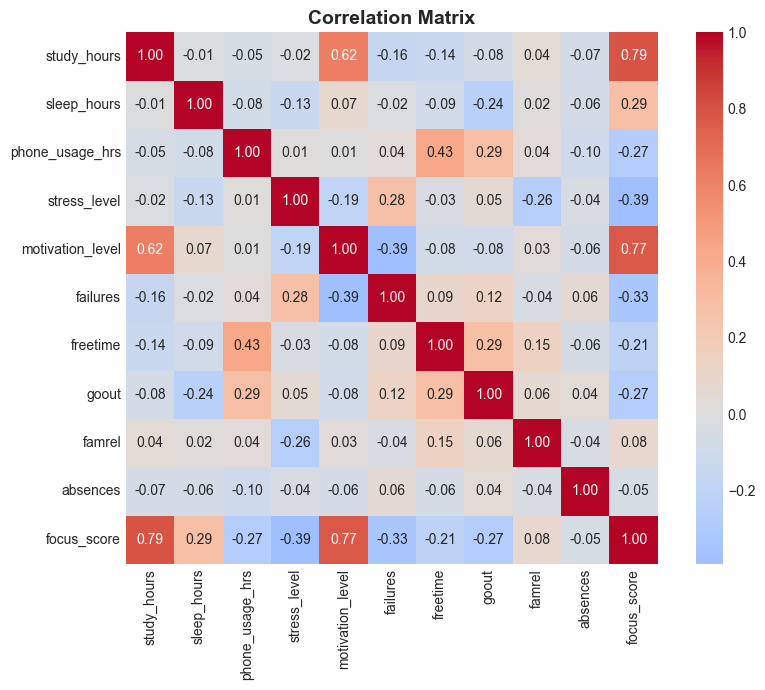

Correlations with focus_score, sorted:
study_hours         0.790
motivation_level    0.774
sleep_hours         0.287
famrel              0.084
absences           -0.050
freetime           -0.212
goout              -0.268
phone_usage_hrs    -0.269
failures           -0.328
stress_level       -0.388
dtype: float64


In [87]:
plt.figure(figsize=(9,7))
corr_matrix = df[feature_cols + ['focus_score']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlations with focus_score, sorted:")
print(df[feature_cols].corrwith(df['focus_score']).sort_values(ascending=False).round(3))

PART 4- Data Preparation
# 🧹 Part 4 — Data Preparation

Prepare the final feature matrix for machine learning.

- Use only self-report / behavioral features available to a real user.
- Exclude G1 and G2 from model inputs.
- Scale features where required for K-Means and SVM.
- Split the data into training and testing sets.

In [88]:
# ─────────────────────────────────────────────────────────────────
# Data Preparation
# ─────────────────────────────────────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features available to the models
feature_cols = [
    'study_hours',
    'sleep_hours',
    'phone_usage_hrs',
    'stress_level',
    'motivation_level',
    'failures',
    'freetime',
    'goout',
    'famrel',
    'absences'
]

X = df[feature_cols].copy()

# Targets
y_focus = df['focus_score'].copy()
y_risk = df['procrastination_risk'].copy()

# Train/test split
X_train, X_test, y_focus_train, y_focus_test = train_test_split(
    X,
    y_focus,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Same split for classification
X_train_cls, X_test_cls, y_risk_train, y_risk_test = train_test_split(
    X,
    y_risk,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_risk
)

# Standardization for K-Means and SVM
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data preparation complete!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"Number of features: {len(feature_cols)}")

✅ Data preparation complete!
Training samples: 316
Testing samples:  79
Number of features: 10


# 🤖 Part 5 — Model Training & Evaluation

Three complementary machine-learning approaches are used:

1. **K-Means Clustering** — discovers student behavior archetypes without labels.
2. **Random Forest Regression** — predicts a student's focus score.
3. **SVM Classification** — predicts procrastination risk.

Together these provide both behavioral segmentation and predictive modeling.

## 5A · K-Means Clustering — Student Behavior Archetypes

K-Means groups students according to similarities in their behavioral patterns.

The clusters are not predefined labels. They are discovered automatically
from the behavioral features.

In [89]:
# ─────────────────────────────────────────────────────────────────
# 5A — K-Means Clustering
# ─────────────────────────────────────────────────────────────────

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Scale the complete feature dataset
X_scaled = scaler.fit_transform(X)

# Try several cluster counts
silhouette_scores = {}

for k in range(2, 7):
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    labels = km.fit_predict(X_scaled)
    silhouette_scores[k] = silhouette_score(X_scaled, labels)

best_k = max(silhouette_scores, key=silhouette_scores.get)

print("Silhouette scores:")
for k, score in silhouette_scores.items():
    print(f"k={k}: {score:.3f}")

print(f"\n✅ Best number of clusters: {best_k}")

Silhouette scores:
k=2: 0.119
k=3: 0.123
k=4: 0.135
k=5: 0.135
k=6: 0.125

✅ Best number of clusters: 4


In [90]:
# Final K-Means model
kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)

df['behavior_cluster'] = kmeans.fit_predict(X_scaled)

print("✅ K-Means clustering complete!")
print("\nStudents per cluster:")
print(df['behavior_cluster'].value_counts().sort_index())

✅ K-Means clustering complete!

Students per cluster:
behavior_cluster
0     31
1     87
2    133
3    144
Name: count, dtype: int64


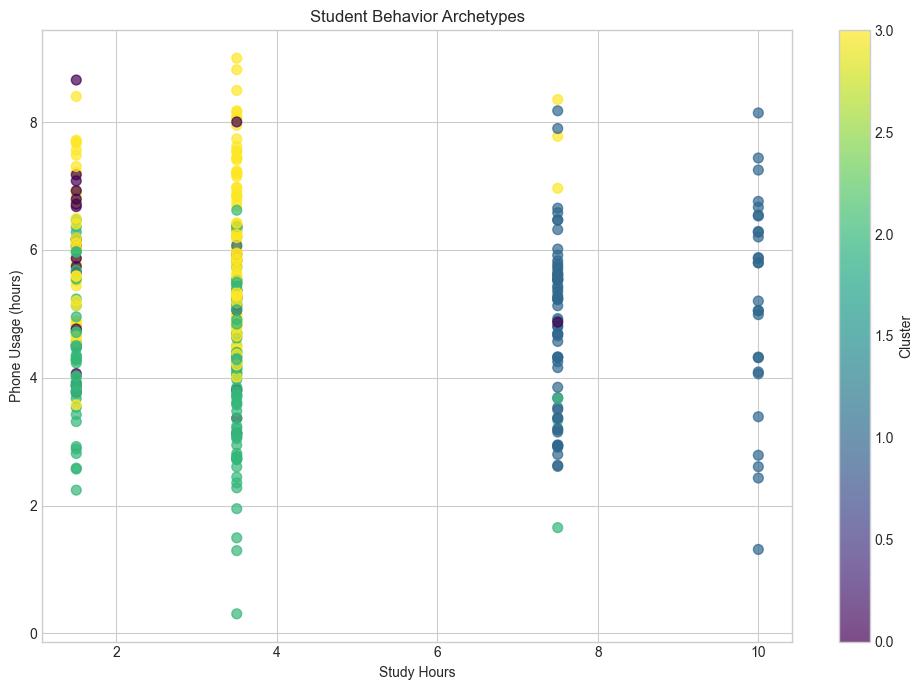

In [91]:
# ─────────────────────────────────────────────────────────────────
# Cluster visualization
# ─────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df['study_hours'],
    df['phone_usage_hrs'],
    c=df['behavior_cluster'],
    cmap='viridis',
    s=50,
    alpha=0.7
)

plt.xlabel('Study Hours')
plt.ylabel('Phone Usage (hours)')
plt.title('Student Behavior Archetypes')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

In [92]:
# Cluster profiles
cluster_profile = df.groupby('behavior_cluster')[feature_cols].mean().round(2)

print("📊 Behavior Archetype Profiles:")
display(cluster_profile)

📊 Behavior Archetype Profiles:


,study_hours,sleep_hours,phone_usage_hrs,stress_level,motivation_level,failures,freetime,goout,famrel,absences
behavior_cluster,,,,,,,,,,
0,2.53,7.52,5.63,3.69,2.99,2.45,3.65,3.55,3.81,5.55
1,8.14,7.61,4.97,1.91,8.19,0.08,3.08,2.93,3.99,3.91
2,2.90,7.97,4.18,1.88,5.51,0.20,2.59,2.50,3.77,7.57
3,3.03,7.38,6.01,2.11,5.49,0.16,3.83,3.69,4.10,5.11


## 5B · Random Forest — Advanced Focus Score Predictor

Random Forest Regression combines many decision trees to predict the continuous
focus score.

It can capture nonlinear relationships between behavioral features and focus.

In [93]:
# ─────────────────────────────────────────────────────────────────
# 5B — Random Forest Regression
# ─────────────────────────────────────────────────────────────────

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=4,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_focus_train)

# Predictions
y_focus_pred = rf_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_focus_test, y_focus_pred)
rmse = np.sqrt(mean_squared_error(y_focus_test, y_focus_pred))
r2 = r2_score(y_focus_test, y_focus_pred)

print("🌲 Random Forest — Focus Score Prediction")
print("-----------------------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

🌲 Random Forest — Focus Score Prediction
-----------------------------------------
MAE  : 7.85
RMSE : 9.81
R²   : 0.887


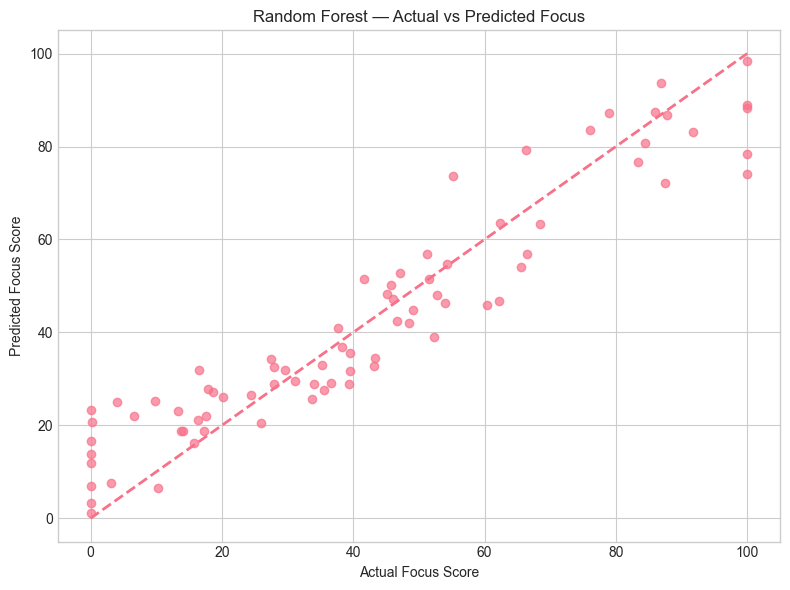

In [94]:
# Actual vs predicted focus scores

plt.figure(figsize=(8, 6))

plt.scatter(
    y_focus_test,
    y_focus_pred,
    alpha=0.7
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle='--',
    linewidth=2
)

plt.xlabel('Actual Focus Score')
plt.ylabel('Predicted Focus Score')
plt.title('Random Forest — Actual vs Predicted Focus')
plt.tight_layout()
plt.show()

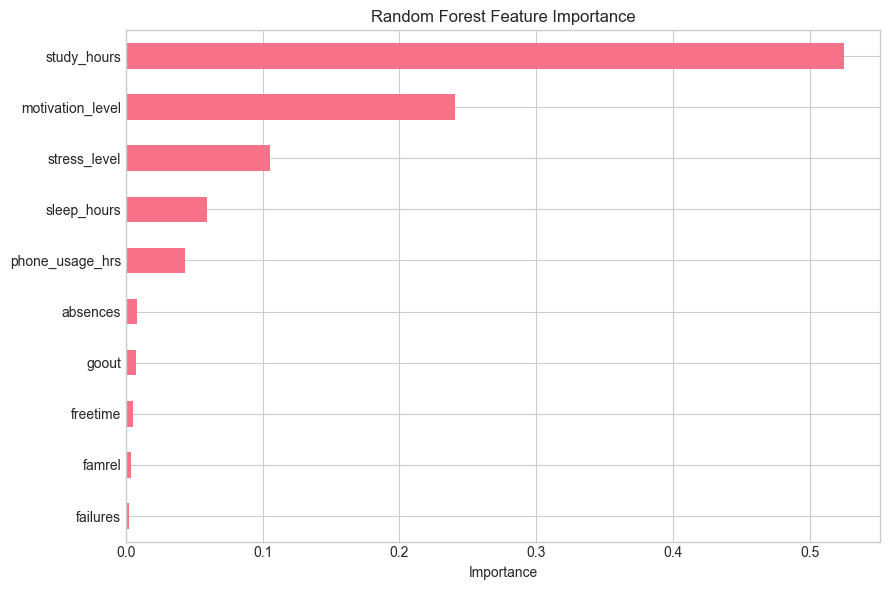

Feature importance:


study_hours         0.525
motivation_level    0.241
stress_level        0.105
sleep_hours         0.059
phone_usage_hrs     0.043
absences            0.008
goout               0.007
freetime            0.005
famrel              0.004
failures            0.002
dtype: float64

In [95]:
# Feature importance
importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))

importance.sort_values().plot(
    kind='barh'
)

plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print("Feature importance:")
display(importance.round(3))

## 5C · SVM — Procrastination Risk Classifier

Support Vector Machine classification predicts whether a student belongs to
a low, medium, or high procrastination-risk group.

Because SVM is sensitive to feature scale, standardized features are used.

In [96]:
# ─────────────────────────────────────────────────────────────────
# 5C — SVM Classification
# ─────────────────────────────────────────────────────────────────

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

svm_scaler = StandardScaler()

X_train_svm = svm_scaler.fit_transform(X_train_cls)
X_test_svm = svm_scaler.transform(X_test_cls)

svm_model = SVC(
    kernel='rbf',
    C=2.0,
    gamma='scale',
    probability=True,
    random_state=RANDOM_STATE
)

svm_model.fit(X_train_svm, y_risk_train)

# Predictions
y_risk_pred = svm_model.predict(X_test_svm)

accuracy = accuracy_score(y_risk_test, y_risk_pred)

print("🎯 SVM — Procrastination Risk Classification")
print("---------------------------------------------")
print(f"Accuracy: {accuracy:.3f}")

print("\nClassification Report:")
print(
    classification_report(
        y_risk_test,
        y_risk_pred,
        zero_division=0
    )
)

🎯 SVM — Procrastination Risk Classification
---------------------------------------------
Accuracy: 0.380

Classification Report:
              precision    recall  f1-score   support

        High       0.46      0.48      0.47        27
         Low       0.48      0.50      0.49        26
      Medium       0.17      0.15      0.16        26

    accuracy                           0.38        79
   macro avg       0.37      0.38      0.37        79
weighted avg       0.37      0.38      0.38        79



<Figure size 700x600 with 0 Axes>

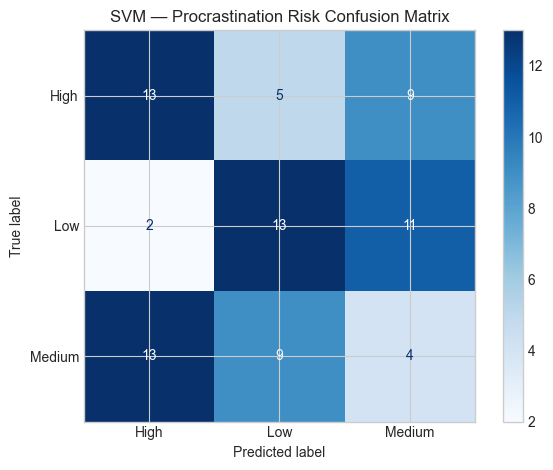

In [97]:
# Confusion matrix

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_risk_test,
    y_risk_pred,
    cmap='Blues'
)

plt.title('SVM — Procrastination Risk Confusion Matrix')
plt.tight_layout()
plt.show()

In [98]:
# ─────────────────────────────────────────────────────────────────
# Model Summary
# ─────────────────────────────────────────────────────────────────

model_summary = pd.DataFrame({
    'Model': [
        'K-Means',
        'Random Forest',
        'SVM'
    ],
    'Task': [
        'Behavior Clustering',
        'Focus Score Regression',
        'Procrastination Classification'
    ],
    'Main Metric': [
        'Silhouette Score',
        'R²',
        'Accuracy'
    ],
    'Score': [
        silhouette_scores[best_k],
        r2,
        accuracy
    ]
})

display(model_summary.round(3))

,Model,Task,Main Metric,Score
0,K-Means,Behavior Clustering,Silhouette Score,0.135
1,Random Forest,Focus Score Regression,R²,0.887
2,SVM,Procrastination Classification,Accuracy,0.380


# 🎛️ Part 6 — Interactive Prediction Dashboard

The dashboard allows a user to enter behavioral information through sliders.

The trained models then provide:

- Predicted Focus Score
- Procrastination Risk
- Behavioral Cluster

This simulates how the system could be used as a real student-facing
decision-support tool.

In [99]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                    FocusIQ — Interactive Dashboard                 ║
# ║              Personalized Focus & Procrastination Predictor        ║
# ╚══════════════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score


# ══════════════════════════════════════════════════════════════════════
# 1. DASHBOARD FEATURES
# ══════════════════════════════════════════════════════════════════════

# Only information a student can realistically provide.
# NO absences, failures, family relation, or free time.

dashboard_features = [
    'study_hours',
    'sleep_hours',
    'phone_usage_hrs',
    'stress_level',
    'motivation_level',
    'goout'
]

feature_labels = {
    'study_hours': '📚 Study Hours',
    'sleep_hours': '😴 Sleep Hours',
    'phone_usage_hrs': '📱 Phone Usage',
    'stress_level': '😰 Stress Level',
    'motivation_level': '🔥 Motivation',
    'goout': '🌳 Going Out'
}


# ══════════════════════════════════════════════════════════════════════
# 2. CHECK DATA
# ══════════════════════════════════════════════════════════════════════

required_columns = dashboard_features + ['focus_score']

missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(
        f"Missing columns in df: {missing}\n"
        f"Available columns are:\n{list(df.columns)}"
    )

print("✅ Dashboard data verified!")
print(f"📊 Dataset size: {len(df)} students")


# ══════════════════════════════════════════════════════════════════════
# 3. TRAIN DASHBOARD MODEL
# ══════════════════════════════════════════════════════════════════════

X_dashboard = df[dashboard_features].copy()
y_dashboard = df['focus_score'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_dashboard,
    y_dashboard,
    test_size=0.20,
    random_state=RANDOM_STATE
)

dashboard_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=RANDOM_STATE
)

dashboard_model.fit(X_train, y_train)

# Evaluate
y_pred = dashboard_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"🌲 Random Forest trained")
print(f"📉 MAE: {mae:.2f}")
print(f"📈 R² Score: {r2:.3f}")


# ══════════════════════════════════════════════════════════════════════
# 4. WIDGETS
# ══════════════════════════════════════════════════════════════════════

study_slider = widgets.FloatSlider(
    value=5.0,
    min=0,
    max=12,
    step=0.5,
    description='📚 Study',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='95%')
)

sleep_slider = widgets.FloatSlider(
    value=7.0,
    min=3,
    max=10,
    step=0.5,
    description='😴 Sleep',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='95%')
)

phone_slider = widgets.FloatSlider(
    value=4.0,
    min=0,
    max=12,
    step=0.5,
    description='📱 Phone',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='95%')
)

stress_slider = widgets.IntSlider(
    value=5,
    min=0,
    max=10,
    step=1,
    description='😰 Stress',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='95%')
)

motivation_slider = widgets.IntSlider(
    value=6,
    min=1,
    max=10,
    step=1,
    description='🔥 Motivation',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='95%')
)

going_out_slider = widgets.FloatSlider(
    value=3.0,
    min=0,
    max=6,
    step=0.5,
    description='🌳 Going Out',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='95%')
)


# ══════════════════════════════════════════════════════════════════════
# 5. DASHBOARD HEADER
# ══════════════════════════════════════════════════════════════════════

header = HTML("""
<div style="
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    padding: 28px;
    border-radius: 18px;
    color: white;
    margin-bottom: 18px;
    box-shadow: 0 8px 25px rgba(0,0,0,0.18);
">
    <h1 style="margin:0; font-size:32px;">
        🧠 FocusIQ
    </h1>

    <p style="
        margin:8px 0 0 0;
        font-size:16px;
        opacity:0.95;
    ">
        Personalized Focus & Productivity Predictor
    </p>

    <p style="
        margin:10px 0 0 0;
        font-size:13px;
        opacity:0.85;
    ">
        Adjust the sliders to see how your daily habits influence your
        predicted focus score.
    </p>
</div>
""")


# ══════════════════════════════════════════════════════════════════════
# 6. INPUT SECTION
# ══════════════════════════════════════════════════════════════════════

input_title = HTML("""
<div style="
    background:#eef2ff;
    padding:15px 20px;
    border-radius:14px;
    border-left:6px solid #667eea;
    margin-bottom:10px;
">
    <h3 style="margin:0; color:#4338ca;">
        🎛️ Your Daily Habits
    </h3>
    <p style="margin:5px 0 0 0; color:#555;">
        Move the sliders to describe your typical day.
    </p>
</div>
""")


left_inputs = widgets.VBox([
    study_slider,
    sleep_slider,
    phone_slider
], layout=widgets.Layout(
    width='50%',
    padding='10px'
))

right_inputs = widgets.VBox([
    stress_slider,
    motivation_slider,
    going_out_slider
], layout=widgets.Layout(
    width='50%',
    padding='10px'
))

inputs = widgets.HBox([
    left_inputs,
    right_inputs
])


# ══════════════════════════════════════════════════════════════════════
# 7. OUTPUT AREA
# ══════════════════════════════════════════════════════════════════════

output = widgets.Output()


# ══════════════════════════════════════════════════════════════════════
# 8. PREDICTION FUNCTION
# ══════════════════════════════════════════════════════════════════════

def update_dashboard(change=None):

    with output:

        clear_output(wait=True)

        # --------------------------------------------------------------
        # Collect user inputs
        # --------------------------------------------------------------

        user_data = pd.DataFrame([{
            'study_hours': study_slider.value,
            'sleep_hours': sleep_slider.value,
            'phone_usage_hrs': phone_slider.value,
            'stress_level': stress_slider.value,
            'motivation_level': motivation_slider.value,

            # IMPORTANT:
            # Actual dataframe column is "goout", NOT "going_out"
            'goout': going_out_slider.value
        }])

        # --------------------------------------------------------------
        # Predict focus score
        # --------------------------------------------------------------

        focus_prediction = float(
            dashboard_model.predict(user_data)[0]
        )

        focus_prediction = np.clip(
            focus_prediction,
            0,
            100
        )

        # --------------------------------------------------------------
        # Procrastination risk
        # --------------------------------------------------------------

        risk_score = (
            0.40 * phone_slider.value / 12 +
            0.30 * stress_slider.value / 10 +
            0.20 * (1 - motivation_slider.value / 10) +
            0.10 * (1 - study_slider.value / 12)
        )

        risk_score = np.clip(risk_score * 100, 0, 100)

        # --------------------------------------------------------------
        # Focus category
        # --------------------------------------------------------------

        if focus_prediction >= 75:
            focus_status = "Excellent Focus 🚀"
            focus_message = "Your current habits support strong concentration."

        elif focus_prediction >= 60:
            focus_status = "Good Focus 👍"
            focus_message = "You're doing fairly well, with some room to improve."

        elif focus_prediction >= 45:
            focus_status = "Moderate Focus 🙂"
            focus_message = "A few habit changes could noticeably improve your focus."

        else:
            focus_status = "Low Focus ⚠️"
            focus_message = "Your current habits may be making concentration difficult."

        # --------------------------------------------------------------
        # Risk category
        # --------------------------------------------------------------

        if risk_score < 30:
            risk_status = "Low Risk 🟢"

        elif risk_score < 60:
            risk_status = "Moderate Risk 🟡"

        else:
            risk_status = "High Risk 🔴"


        # ══════════════════════════════════════════════════════════════
        # RESULT CARDS
        # ══════════════════════════════════════════════════════════════

        if focus_prediction >= 75:
            focus_color = "#16a34a"
        elif focus_prediction >= 60:
            focus_color = "#2563eb"
        elif focus_prediction >= 45:
            focus_color = "#f59e0b"
        else:
            focus_color = "#dc2626"


        if risk_score < 30:
            risk_color = "#16a34a"
        elif risk_score < 60:
            risk_color = "#f59e0b"
        else:
            risk_color = "#dc2626"


        cards = HTML(f"""

        <div style="
            display:flex;
            gap:15px;
            margin-top:15px;
            margin-bottom:20px;
        ">

            <div style="
                flex:1;
                background:{focus_color};
                color:white;
                padding:22px;
                border-radius:16px;
                text-align:center;
                box-shadow:0 6px 18px rgba(0,0,0,0.15);
            ">

                <div style="font-size:14px; opacity:0.9;">
                    PREDICTED FOCUS
                </div>

                <div style="
                    font-size:42px;
                    font-weight:bold;
                    margin:5px;
                ">
                    {focus_prediction:.1f}
                </div>

                <div style="font-size:16px;">
                    / 100
                </div>

            </div>


            <div style="
                flex:1;
                background:{risk_color};
                color:white;
                padding:22px;
                border-radius:16px;
                text-align:center;
                box-shadow:0 6px 18px rgba(0,0,0,0.15);
            ">

                <div style="font-size:14px; opacity:0.9;">
                    PROCRASTINATION RISK
                </div>

                <div style="
                    font-size:34px;
                    font-weight:bold;
                    margin:10px;
                ">
                    {risk_status}
                </div>

                <div style="font-size:14px;">
                    Risk Score: {risk_score:.0f}%
                </div>

            </div>

        </div>


        <div style="
            background:#f8fafc;
            padding:18px;
            border-radius:14px;
            border:1px solid #e2e8f0;
            margin-bottom:15px;
        ">

            <h3 style="margin:0 0 6px 0;">
                {focus_status}
            </h3>

            <p style="margin:0;color:#64748b;">
                {focus_message}
            </p>

        </div>
        """)

        display(cards)


        # ══════════════════════════════════════════════════════════════
        # VISUALIZATION
        # ══════════════════════════════════════════════════════════════

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(13, 4.5)
        )

        # --------------------------------------------------------------
        # GRAPH 1 — Your habits
        # --------------------------------------------------------------

        labels = [
            'Study',
            'Sleep',
            'Phone',
            'Stress',
            'Motivation',
            'Going Out'
        ]

        values = [
            study_slider.value / 12 * 10,
            sleep_slider.value / 10 * 10,
            phone_slider.value / 12 * 10,
            stress_slider.value,
            motivation_slider.value,
            going_out_slider.value / 5 * 10
        ]

        bars = axes[0].bar(
            labels,
            values
        )

        axes[0].set_ylim(0, 10)
        axes[0].set_ylabel("Normalized Level")
        axes[0].set_title(
            "📊 Your Habit Profile",
            fontsize=13,
            fontweight='bold'
        )

        axes[0].tick_params(axis='x', rotation=35)

        for bar, value in zip(bars, values):
            axes[0].text(
                bar.get_x() + bar.get_width()/2,
                value + 0.2,
                f"{value:.1f}",
                ha='center',
                fontsize=9
            )


        # --------------------------------------------------------------
        # GRAPH 2 — Focus vs Risk
        # --------------------------------------------------------------

        axes[1].bar(
            ['Focus Score', 'Procrastination Risk'],
            [focus_prediction, risk_score]
        )

        axes[1].set_ylim(0, 100)

        axes[1].set_ylabel("Score")
        axes[1].set_title(
            "🎯 Focus vs Procrastination",
            fontsize=13,
            fontweight='bold'
        )

        for i, value in enumerate(
            [focus_prediction, risk_score]
        ):
            axes[1].text(
                i,
                value + 3,
                f"{value:.1f}",
                ha='center',
                fontsize=11,
                fontweight='bold'
            )

        plt.tight_layout()
        plt.show()


        # ══════════════════════════════════════════════════════════════
        # PERSONALIZED SUGGESTIONS
        # ══════════════════════════════════════════════════════════════

        suggestions = []

        if study_slider.value < 3:
            suggestions.append(
                "📚 Try increasing focused study time gradually."
            )

        if sleep_slider.value < 6:
            suggestions.append(
                "😴 Your sleep is relatively low. More sleep may support better concentration."
            )

        if phone_slider.value > 6:
            suggestions.append(
                "📱 Consider reducing recreational phone usage during study periods."
            )

        if stress_slider.value >= 7:
            suggestions.append(
                "😰 Your stress level is high. Short breaks or relaxation periods may help."
            )

        if motivation_slider.value <= 4:
            suggestions.append(
                "🔥 Motivation is low. Try smaller, achievable study goals."
            )

        if going_out_slider.value == 1:
            suggestions.append(
                "🌳 Consider taking occasional breaks away from your study environment."
            )

        if going_out_slider.value >= 5:
            suggestions.append(
                "🌳 Make sure social/outdoor time is balanced with your study schedule."
            )

        if not suggestions:
            suggestions.append(
                "✨ Your current habit combination looks balanced. Keep it up!"
            )


        suggestion_html = "".join(
            f"""
            <div style="
                padding:9px 12px;
                margin:5px 0;
                background:#f1f5f9;
                border-radius:9px;
            ">
                {s}
            </div>
            """
            for s in suggestions
        )

        display(HTML(f"""
        <div style="
            margin-top:10px;
            padding:18px;
            border-radius:14px;
            background:#ffffff;
            border:1px solid #e2e8f0;
        ">

            <h3 style="margin:0 0 10px 0;">
                💡 Personalized Suggestions
            </h3>

            {suggestion_html}

        </div>
        """))


# ══════════════════════════════════════════════════════════════════════
# 9. MAKE SLIDERS INTERACTIVE
# ══════════════════════════════════════════════════════════════════════

for slider in [
    study_slider,
    sleep_slider,
    phone_slider,
    stress_slider,
    motivation_slider,
    going_out_slider
]:
    slider.observe(
        update_dashboard,
        names='value'
    )


# ══════════════════════════════════════════════════════════════════════
# 10. DISPLAY DASHBOARD
# ══════════════════════════════════════════════════════════════════════

display(header)
display(input_title)
display(inputs)
display(output)

# Initial prediction
update_dashboard()


print("\n✅ FocusIQ Dashboard Ready!")
print("🎛️ Move the sliders to see live predictions.")

✅ Dashboard data verified!
📊 Dataset size: 395 students
🌲 Random Forest trained
📉 MAE: 7.88
📈 R² Score: 0.886


Output()


✅ FocusIQ Dashboard Ready!
🎛️ Move the sliders to see live predictions.
